In [41]:
"""랜덤포레스트 활용:
class_weight, SMOTE 오버샘플링, 그리드서치, threshold 완화 등 모두 사용해 보았으나,
성공한 카페에 대한 예측 정확도가 너무 떨어지는 관계로 우선 skip함
"""
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
# 랜덤 포레스트 학습
# 데이터 로드 및 전처리
cafe = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_피처병합.csv')
cafe_cleaned = cafe.dropna(subset=['총점', '성공_여부', '교차로_존재_여부', 'est_총_유동인구_수']).copy()
cafe_cleaned['교차로_존재_여부'] = cafe_cleaned['교차로_존재_여부'].astype(int)
cafe_cleaned[['집객시설_수', '지하철_역_수','버스_정거장_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']] = cafe_cleaned[['집객시설_수', '지하철_역_수','버스_정거장_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']].fillna(0)

# 층수 처리
def convert_floor(floor):
    try:
        # B1, B2 등은 지하층을 의미하므로 음수로 변환
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        elif isinstance(floor, str) and floor.startswith('지'):
            return -1
        else:
            return int(floor)
    except:
        return 1  # 오류가 나는 경우는 1층으로 처리
cafe_cleaned['층정보'] = cafe_cleaned['층정보'].apply(convert_floor)

train_cols = ['층정보','지하철역_거리(m)','버스정류장_거리(m)','반경500m내_카페수', '평일_대비_주말_유동인구_비율','도로2m이내접촉길이_m','집객시설_수', '지하철_역_수','버스_정거장_수','평균_평일_유동인구_수', '평균_주말_유동인구_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수','est_시간대_11_14_유동인구_수']
X = cafe_cleaned[train_cols]
y = cafe_cleaned['성공_여부']

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Best Parameters: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}

# 오버샘플링
# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
# 하이퍼파라미터 그리드 설정
rf_model = RandomForestClassifier(
    class_weight = None, max_depth= 10, min_samples_leaf= 4, min_samples_split= 10, n_estimators= 100
)

# 학습
rf_model.fit(X_train, y_train)


# 확률값 예측 (1 클래스에 대한 확률만 추출)
y_probs = rf_model.predict_proba(X_test)[:, 1]

# 원하는 threshold 설정
threshold = 0.3  # 기본값 0.5보다 낮춰서 더 많은 1을 예측하도록 함
y_pred_thresholded = (y_probs >= threshold).astype(int)

# 성능 평가
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_thresholded))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_thresholded))

# 성공할 카페를 판단하는 데 좋지 않은 모습, skip
# threshold 사용하면 정확도 너무 많이 떨어진다. (56%)

Confusion Matrix:
[[789 828]
 [234 429]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.77      0.49      0.60      1617
         1.0       0.34      0.65      0.45       663

    accuracy                           0.53      2280
   macro avg       0.56      0.57      0.52      2280
weighted avg       0.65      0.53      0.55      2280



threshold = 0.44
Confusion Matrix:
[[884 733]
 [340 323]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.72      0.55      0.62      1617
         1.0       0.31      0.49      0.38       663

    accuracy                           0.53      2280
   macro avg       0.51      0.52      0.50      2280
weighted avg       0.60      0.53      0.55      2280

ROC AUC Score: 0.5475


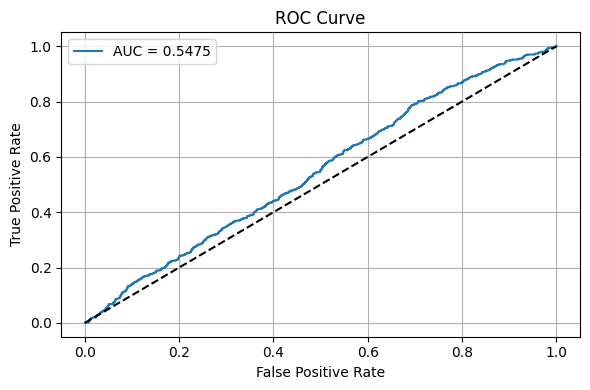

In [42]:
"""XGB 사용 결과
랜덤포레스트보다 조금 나은 성능 (데이터 라벨 불균형 어느 정도 잡아줌)
성공할 만한 매물을 추천하는 데는 나쁘지 않은 정도, 다른 것들을 사용해 보고 다음에 피처 조정
"""
# XGBoost 사용
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

cafe = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\카페_피처병합.csv')
cafe_cleaned = cafe.dropna(subset=['총점', '성공_여부', '교차로_존재_여부', 'est_총_유동인구_수']).copy()
cafe_cleaned['교차로_존재_여부'] = cafe_cleaned['교차로_존재_여부'].astype(int)
cafe_cleaned[['집객시설_수', '지하철_역_수','버스_정거장_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']] = cafe_cleaned[['집객시설_수', '지하철_역_수','버스_정거장_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']].fillna(0)

# 층수 처리
def convert_floor(floor):
    try:
        # B1, B2 등은 지하층을 의미하므로 음수로 변환
        if isinstance(floor, str) and floor.startswith('B'):
            return -int(floor[1:])
        elif isinstance(floor, str) and floor.startswith('지'):
            return -1
        else:
            return int(floor)
    except:
        return 1  # 오류가 나는 경우는 1층으로 처리
cafe_cleaned['층정보'] = cafe_cleaned['층정보'].apply(convert_floor)

train_cols = ['지하철역_거리(m)','버스정류장_거리(m)','반경500m내_카페수', '평일_대비_주말_유동인구_비율','도로2m이내접촉길이_m','집객시설_수', '지하철_역_수','버스_정거장_수','평균_평일_유동인구_수', '평균_주말_유동인구_수','유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수']
X = cafe_cleaned[train_cols]
y = cafe_cleaned['성공_여부']

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 클래스 비율: 7:3 => scale_pos_weight = 7 / 3 ≈ 2.33
xgb_model = XGBClassifier(scale_pos_weight=2.33, max_depth=6, n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# 평가 ###########

# 1. 확률예측
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# 2. threshold 조정 (기본: 0.35)
threshold = 0.44
y_pred_custom = (y_proba >= threshold).astype(int)
print(f'threshold = {threshold}')
# 3. confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

# 4. classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom))

# 5. ROC AUC
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {auc_score:.4f}")

# 6. ROC Curve 시각화
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()



In [43]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(is_unbalance=True, max_depth=6, n_estimators=100, random_state=42)
model.fit(X_train, y_train)


Exception in thread Thread-428:
Traceback (most recent call last):
  File "c:\Users\iq750\anaconda3\envs\ml\lib\threading.py", line 980, in _bootstrap_inner
    self.run()
  File "c:\Users\iq750\anaconda3\envs\ml\lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\iq750\anaconda3\envs\ml\lib\threading.py", line 917, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\iq750\anaconda3\envs\ml\lib\subprocess.py", line 1495, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\iq750\anaconda3\envs\ml\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc3 in position 24: invalid continuation byte


[LightGBM] [Info] Number of positive: 2829, number of negative: 6290
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000465 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1956
[LightGBM] [Info] Number of data points in the train set: 9119, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.310231 -> initscore=-0.799038
[LightGBM] [Info] Start training from score -0.799038
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

c:\Users\iq750\anaconda3\envs\ml\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
'NoneType' object has no attribute 'splitlines'
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\iq750\anaconda3\envs\ml\lib\site-packages\joblib\externals\loky\backend\context.py", line 262, in _count_physical_cores
    cpu_info = cpu_info.stdout.splitlines()


LGBMClassifier(is_unbalance=True, max_depth=6, random_state=42)

In [44]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(auto_class_weights='Balanced', iterations=100, depth=6, random_state=42, verbose=0)
model.fit(X_train, y_train)


In [ ]:
# 데이터 가공 및 정리
import pandas as pd
import re
import numpy as np
import sys
sale = pd.read_csv(r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\매물추천\매물_피처병합_수정.csv', low_memory=False)

# print(sale.columns.tolist())
# 상권 내 매물이 아니면 drop
sale = sale.dropna(subset=['상권_코드','articleNo'])

# 금액 전환
def parse_price_to_manwon(price_str): # 금액 숫자로 전환
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str).strip().replace(",", "").replace(" ", "")
    
    if "억" in price_str:
        match = re.match(r"(\d+)억(\d+)?", price_str)
        if match:
            billion = int(match.group(1)) * 10000
            thousand = int(match.group(2)) if match.group(2) else 0
            return billion + thousand
        else:
            return int(price_str.replace("억", "")) * 10000
    elif price_str.isdigit():
        return int(price_str)
    else:
        return pd.to_numeric(price_str, errors='coerce')
sale['rentPrc'] = sale['rentPrc'].apply(parse_price_to_manwon)
sale['dealOrWarrantPrc'] = sale['dealOrWarrantPrc'].apply(parse_price_to_manwon)

# 결측치 처리
sale[['집객시설_수', '관공서_수', '은행_수', '종합병원_수', '일반_병원_수', '약국_수', '유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수', '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '지하철_역_수', '버스_정거장_수','반경500m내_카페수', '접한길이_m', '도로2m이내접착길이_m','지하철역_거리(m)', '버스정류장_거리(m)']] = sale[['집객시설_수', '관공서_수', '은행_수', '종합병원_수', '일반_병원_수', '약국_수', '유치원_수', '초등학교_수', '중학교_수', '고등학교_수', '대학교_수', '백화점_수', '슈퍼마켓_수', '극장_수', '숙박_시설_수', '지하철_역_수', '버스_정거장_수','반경500m내_카페수', '접한길이_m', '도로2m이내접촉길이_m','지하철역_거리(m)', '버스정류장_거리(m)']].fillna(0)
# 컬럼명 오타 수정 (접착 → 접촉) # 완전 수정함

sale['est_총_유동인구_수'] = sale['est_총_유동인구_수'].fillna(sale['est_총_유동인구_수'].mean())

# 데이터 형식
sale['상권_코드'] = sale['상권_코드'].astype(int)
sale['교차로_존재_여부'] = sale['교차로_존재_여부'].astype(int)

# 사용자 실습
def recommend_top_properties(
    df, model, selected_areas, trade_type,
    max_rent=None, max_deposit=None, max_deal_price=None, top_n=5
):
    # 1. 상권, 거래유형 필터링
    filtered = df[
        (df['상권_코드'].isin(selected_areas)) &
        (df['tradeTypeName'] == trade_type)
    ].copy()

    # 2. 금액 조건 필터링
    if trade_type == '월세':
        filtered = filtered[
            (filtered['rentPrc'] <= max_rent) &
            (filtered['dealOrWarrantPrc'] <= max_deposit)
        ]
    elif trade_type == '매매':
        filtered = filtered[
            (filtered['dealOrWarrantPrc'] <= max_deal_price)
        ]

    # 3. 피처 선택
    X_test = filtered[model.feature_names_in_].copy()

    # 4. 성공 확률 예측
    filtered['성공확률'] = model.predict_proba(X_test)[:, 1]

    # 5. 확률 기준 정렬 및 상위 n개 추출
    top_recommendations = filtered.sort_values(by='성공확률', ascending=False).head(top_n)

    return top_recommendations.reset_index(drop=True)

recommendations = recommend_top_properties(
    sale,
    model=xgb_model, # 사용할 모델
    selected_areas=[3120104, 3120189], # 선택한 상권
    trade_type='월세', # 월세 / 전세 / 단기임대 / 매매 (월세, 매매가 제일 많음)
    max_rent=200, # 월세 상한선
    max_deposit=1000, # 보증금 상한선
    top_n=5 # 추천 받을 개수
)

print(recommendations[['articleNo', 'rentPrc', 'dealOrWarrantPrc', '성공확률']])
# 더 제공해 줄 수 있는 것 check


      articleNo  rentPrc  dealOrWarrantPrc      성공확률
0  2.519903e+09    120.0            1000.0  0.920718
1  2.521752e+09    120.0            1000.0  0.920718
2  2.521569e+09    120.0            1000.0  0.920718
3  2.522206e+09    126.0            1000.0  0.877406
4  2.524377e+09    110.0            1000.0  0.847014
